# IMDB Movie Review Sentiment Analysis

### Dataset: IMDB Movie Reviews

## Objective
The purpose of this project is to classify movie reviews as positive or negative using both a traditional machine learning model and a deep learning model. The project compares TF-IDF with Logistic Regression against a Bidirectional LSTM model.

In addition to supervised learning models, unsupervised learning techniques are used to uncover hidden patterns within the dataset.

K-Means clustering is applied to group similar movie reviews based on textual features. This allows us to identify natural groupings in the data and explore patterns beyond simple positive and negative classification.

## 1. Upload Dataset

This section uploads the IMDB dataset into the Colab environment.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset.csv


## 2. Load Dataset

The IMDB dataset is loaded into a pandas DataFrame. The dataset contains movie reviews and sentiment labels.

In [ ]:
import pandas as pd

df = pd.read_csv("IMDB Dataset.csv")
df.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df.info()
df['sentiment'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


,count
sentiment,
positive,25000
negative,25000


## 3. Text Preprocessing

The reviews are cleaned by converting text to lowercase, removing HTML tags, punctuation, and extra spaces.

In [ ]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)          # remove HTML tags
    text = re.sub(r"[^a-zA-Z\s]", " ", text)    # keep letters/spaces only
    text = re.sub(r"\s+", " ", text).strip()    # remove extra spaces
    return text

df["clean_review"] = df["review"].apply(clean_text)
df[["review", "clean_review", "sentiment"]].head()

,review,clean_review,sentiment
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...,positive
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,basically there s a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei s love in the time of money is a...,positive


## 4. Encode Sentiment Labels

The target labels are converted into numeric form:
- positive = 1
- negative = 0

In [ ]:
df["label"] = df["sentiment"].map({"positive": 1, "negative": 0})
df[["sentiment", "label"]].head()

,sentiment,label
0,positive,1
1,positive,1
2,positive,1
3,negative,0
4,positive,1


## 5. Train-Test Split

The dataset is split into training and testing subsets for model evaluation.

In [ ]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["clean_review"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

## 6. Baseline Model Preparation: TF-IDF

TF-IDF is used to convert text into numerical features for the baseline logistic regression model.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

custom_stop_words = list(ENGLISH_STOP_WORDS.union({
    'film', 'films', 'movie', 'movies', 'really', 'just', 'like', 'time'
}))

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words=custom_stop_words
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print(X_train.shape, X_test.shape)

(40000, 5000) (10000, 5000)


## 6A. Unsupervised Learning: Clustering Analysis

In [ ]:
from sklearn.cluster import KMeans

# Use TF-IDF features (already created earlier)
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_train)

# Assign clusters
df["cluster"] = kmeans.predict(vectorizer.transform(df["clean_review"]))

df[["clean_review", "cluster"]].head()

,clean_review,cluster
0,one of the other reviewers has mentioned that ...,0
1,a wonderful little production the filming tech...,0
2,i thought this was a wonderful way to spend ti...,2
3,basically there s a family where a little boy ...,0
4,petter mattei s love in the time of money is a...,0


## 6B. Clustering Results

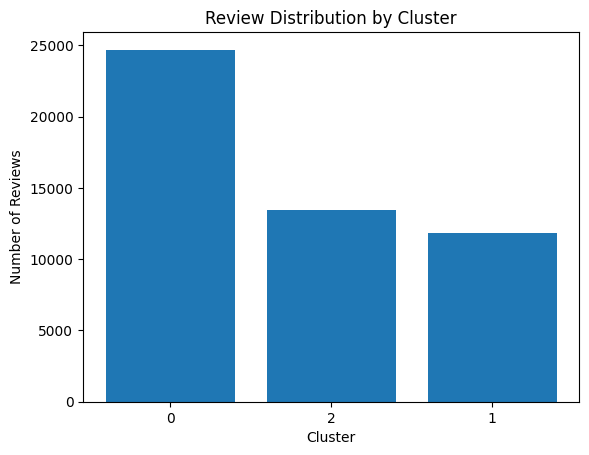

In [ ]:
import matplotlib.pyplot as plt

cluster_counts = df["cluster"].value_counts()

plt.figure()
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)
plt.xlabel("Cluster")
plt.ylabel("Number of Reviews")
plt.title("Review Distribution by Cluster")
plt.show()

## 6C. Clustering Insights

In [ ]:
import numpy as np

terms = vectorizer.get_feature_names_out()

for i in range(3):
    center = kmeans.cluster_centers_[i]
    top_terms = [terms[ind] for ind in center.argsort()[-10:]]
    print(f"\nCluster {i} Top Words:")
    print(top_terms)


Cluster 0 Top Words:
['little', 'does', 'characters', 'way', 'people', 'character', 'good', 'man', 'life', 'story']

Cluster 1 Top Words:
['people', 'seen', 'make', 'horror', 'plot', 'worst', 'don', 'acting', 'good', 'bad']

Cluster 2 Top Words:
['best', 'seen', 'series', 'don', 'love', 'funny', 'think', 'watch', 'good', 'great']


## 7. Baseline Model: Logistic Regression

A logistic regression classifier is trained using TF-IDF features.

In [ ]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## 8. Baseline Model Evaluation

The logistic regression model is evaluated using accuracy, classification report, and confusion matrix.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = baseline_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8922

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.89      0.89      5000
           1       0.89      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000


Confusion Matrix:

[[4429  571]
 [ 507 4493]]


## 9. Tokenization and Sequence Padding

For the LSTM model, reviews are converted into sequences of integers and padded to a fixed length.

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000
max_len = 300

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

print(X_train_pad.shape, X_test_pad.shape)

(40000, 300) (10000, 300)


## 10. Deep Learning Model: Bidirectional LSTM

A Bidirectional LSTM model is built to capture contextual and sequential relationships in the text.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

lstm_model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 11. Training Setup

Early stopping is used to reduce overfitting and restore the best model weights.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

## 12. Train the LSTM Model

The Bidirectional LSTM model is trained on padded review sequences.

In [ ]:
history = lstm_model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 33s 49ms/step - accuracy: 0.7563 - loss: 0.5090 - val_accuracy: 0.6890 - val_loss: 0.5946
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.8228 - loss: 0.4092 - val_accuracy: 0.8634 - val_loss: 0.3594
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 34s 68ms/step - accuracy: 0.8660 - loss: 0.3362 - val_accuracy: 0.8594 - val_loss: 0.3363
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.8391 - loss: 0.3789 - val_accuracy: 0.8684 - val_loss: 0.3261
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 47ms/step - accuracy: 0.9103 - loss: 0.2511 - val_accuracy: 0.8824 - val_loss: 0.2945
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - accuracy: 0.9310 - loss: 0.2018 - val_accuracy: 0.8834 - val_loss: 0.3070
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 24s 47ms/step - accuracy: 0.9480 - loss: 0.1645 - val_accuracy: 0.8763 - val_loss: 0.3328
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.9607 - loss: 0.1295 - 

## 13. LSTM Model Evaluation

The LSTM model is evaluated on the test set using accuracy and loss.

In [ ]:
loss, accuracy = lstm_model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.8791 - loss: 0.3053
Test Accuracy: 0.8791000247001648
Test Loss: 0.30532822012901306


## 14. LSTM Classification Metrics

The LSTM model is further evaluated using a classification report and confusion matrix.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_prob = lstm_model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype("int32")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.85      0.88      5000
           1       0.86      0.90      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000


Confusion Matrix:

[[4268  732]
 [ 477 4523]]


## 15. Training History Visualization

Training and validation accuracy/loss are plotted to analyze learning behavior and overfitting.

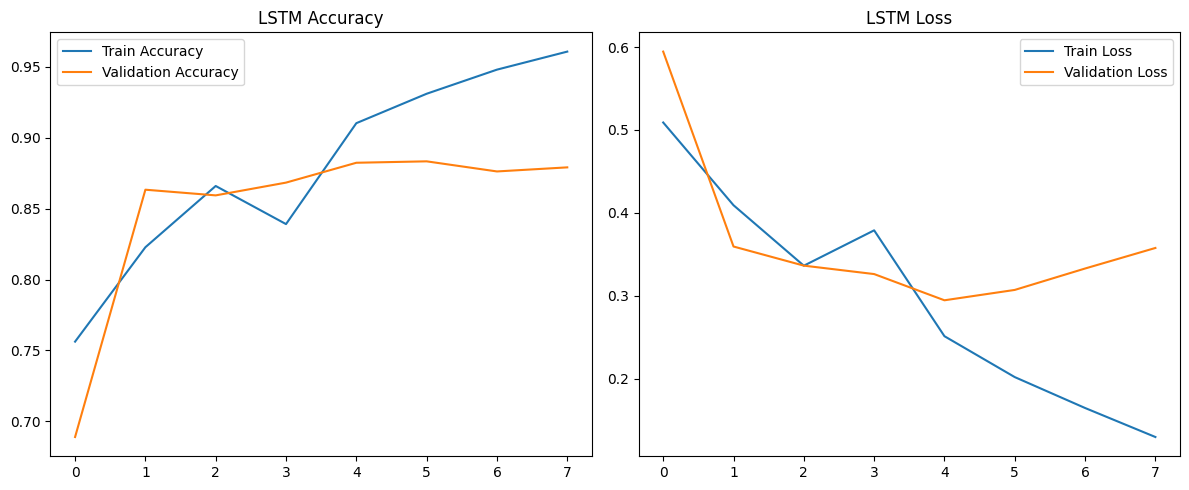

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("LSTM Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Loss")
plt.legend()

plt.tight_layout()
plt.show()

## 16. Custom Test Sentences

Custom movie review examples are created to test model predictions on unseen text.

In [ ]:
test_sentences = [
    "This movie was amazing, I loved every minute!",
    "Worst movie ever, complete waste of time.",
    "It was okay, not great but not terrible.",
    "Absolutely fantastic performance and story!",
    "I did not enjoy this movie at all."
]

In [ ]:
clean_test = [clean_text(s) for s in test_sentences]

## 17. Convert Custom Sentences to Sequences

The custom sentences are tokenized and padded using the same preprocessing pipeline as the training data.

In [ ]:
test_seq = tokenizer.texts_to_sequences(clean_test)
test_pad = pad_sequences(test_seq, maxlen=max_len, padding="post", truncating="post")

## 18. LSTM Predictions on Custom Sentences

The trained LSTM model generates sentiment predictions for the custom reviews.

In [ ]:
pred_probs = lstm_model.predict(test_pad)
pred_labels = (pred_probs > 0.5).astype("int32")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


## 19. Display LSTM Sentiment Predictions

Each custom review is displayed with its predicted sentiment and confidence score.

In [ ]:
for i, sentence in enumerate(test_sentences):
    sentiment = "Positive 😊" if pred_labels[i][0] == 1 else "Negative 😠"
    confidence = pred_probs[i][0]

    print("Review:", sentence)
    print("Prediction:", sentiment)
    print("Confidence:", round(confidence, 3))
    print("-" * 50)

Review: This movie was amazing, I loved every minute!
Prediction: Positive 😊
Confidence: 0.959
--------------------------------------------------
Review: Worst movie ever, complete waste of time.
Prediction: Negative 😠
Confidence: 0.023
--------------------------------------------------
Review: It was okay, not great but not terrible.
Prediction: Negative 😠
Confidence: 0.066
--------------------------------------------------
Review: Absolutely fantastic performance and story!
Prediction: Positive 😊
Confidence: 0.933
--------------------------------------------------
Review: I did not enjoy this movie at all.
Prediction: Positive 😊
Confidence: 0.576
--------------------------------------------------


## 20. Logistic Regression Predictions on Custom Sentences

The same custom reviews are tested using the baseline logistic regression model for comparison.

In [ ]:
# Logistic Regression predictions
test_tfidf = vectorizer.transform(clean_test)
log_pred = baseline_model.predict(test_tfidf)
log_prob = baseline_model.predict_proba(test_tfidf)[:,1]

## 21. Model Comparison on Custom Sentences

Predictions from the LSTM and logistic regression models are compared side by side.

In [ ]:
for i, sentence in enumerate(test_sentences):

    lstm_sent = "Positive 😊" if pred_labels[i][0] == 1 else "Negative 😠"
    log_sent = "Positive 😊" if log_pred[i] == 1 else "Negative 😠"

    print("Review:", sentence)
    print("LSTM Prediction:", lstm_sent, "| Confidence:", round(pred_probs[i][0], 3))
    print("Logistic Prediction:", log_sent, "| Confidence:", round(log_prob[i], 3))
    print("-" * 60)

Review: This movie was amazing, I loved every minute!
LSTM Prediction: Positive 😊 | Confidence: 0.959
Logistic Prediction: Positive 😊 | Confidence: 0.975
------------------------------------------------------------
Review: Worst movie ever, complete waste of time.
LSTM Prediction: Negative 😠 | Confidence: 0.023
Logistic Prediction: Negative 😠 | Confidence: 0.0
------------------------------------------------------------
Review: It was okay, not great but not terrible.
LSTM Prediction: Negative 😠 | Confidence: 0.066
Logistic Prediction: Negative 😠 | Confidence: 0.038
------------------------------------------------------------
Review: Absolutely fantastic performance and story!
LSTM Prediction: Positive 😊 | Confidence: 0.933
Logistic Prediction: Positive 😊 | Confidence: 0.955
------------------------------------------------------------
Review: I did not enjoy this movie at all.
LSTM Prediction: Positive 😊 | Confidence: 0.576
Logistic Prediction: Negative 😠 | Confidence: 0.487
----------

## 22. Accuracy Comparison

A bar chart is used to compare the overall performance of the logistic regression and LSTM models.

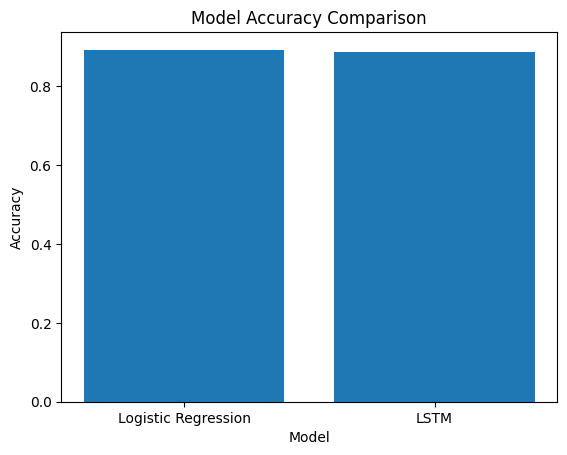

In [ ]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "LSTM"]
accuracies = [0.892, 0.886]  # your actual results

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.show()

## 23. Conclusion

This project compared a traditional machine learning model (TF-IDF with Logistic Regression) and a deep learning model (Bidirectional LSTM) for sentiment analysis on the IMDB dataset.

The logistic regression model achieved slightly higher accuracy, while the LSTM model demonstrated strong contextual understanding and competitive performance. The comparison of custom test sentences showed that the LSTM model was better at handling contextual phrasing, especially in examples involving negation.

In addition to supervised models, unsupervised learning using K-Means clustering was applied to identify natural groupings of reviews, revealing distinct patterns in sentiment and thematic focus across the dataset.

Overall, the project demonstrates that both traditional NLP and deep learning methods can be effective, and that model selection should depend on the goals of the task, complexity of the language, and desired interpretability.